# multi-salary dataset - but this process is invalid



## Loading Dataset

In [42]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("datasets/SalaryMulti.csv")
df.head()


,Total Experience,Team Lead Experience,Project Manager Experience,Certifications,Salary
0,7,2,4,1,77318.070547
1,4,0,2,3,64951.950980
2,13,4,8,3,106058.185204
3,11,3,2,1,89649.944851
4,8,1,6,3,82206.019687


## Data cleaning

In [43]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Total Experience            1000 non-null   int64  
 1   Team Lead Experience        1000 non-null   int64  
 2   Project Manager Experience  1000 non-null   int64  
 3   Certifications              1000 non-null   int64  
 4   Salary                      1000 non-null   float64
dtypes: float64(1), int64(4)
memory usage: 39.2 KB


In [44]:
df.shape

(1000, 5)

In [45]:
df.isnull().count()

Total Experience              1000
Team Lead Experience          1000
Project Manager Experience    1000
Certifications                1000
Salary                        1000
dtype: int64

In [46]:
df.drop_duplicates()

,Total Experience,Team Lead Experience,Project Manager Experience,Certifications,Salary
0,7,2,4,1,77318.070547
1,4,0,2,3,64951.950980
2,13,4,8,3,106058.185204
3,11,3,2,1,89649.944851
4,8,1,6,3,82206.019687
...,...,...,...,...,...
995,8,1,6,4,90941.688891
996,12,3,1,2,92074.890941
997,14,10,1,2,115914.944924
998,7,5,0,2,82706.285700


In [47]:
df.dtypes

Total Experience                int64
Team Lead Experience            int64
Project Manager Experience      int64
Certifications                  int64
Salary                        float64
dtype: object

**Conclusion:** Data is already clean

## Check for the type of data - linear or not


In [48]:
df.corr()*100

,Total Experience,Team Lead Experience,Project Manager Experience,Certifications,Salary
Total Experience,100.000000,65.285648,47.766245,-1.926535,94.184922
Team Lead Experience,65.285648,100.000000,-10.065885,-2.922642,75.377169
Project Manager Experience,47.766245,-10.065885,100.000000,1.544062,40.578571
Certifications,-1.926535,-2.922642,1.544062,100.000000,0.967840
Salary,94.184922,75.377169,40.578571,0.967840,100.000000


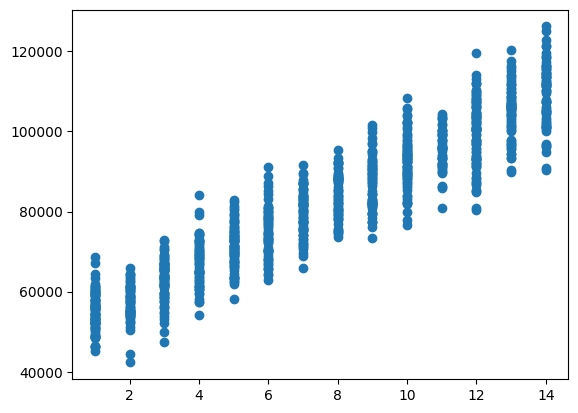

In [49]:
import matplotlib.pyplot as plt

plt.scatter(df['Total Experience'] , df['Salary'],)
plt.show()

## Data Preparation - without separating train and test data 

### Separating data into X and y

In [50]:
X = df[['Total Experience', 'Team Lead Experience', 'Project Manager Experience', 'Certifications' ]]
                # OR
# X = df.drop('Salary', axis = 1)   
X    #2d

,Total Experience,Team Lead Experience,Project Manager Experience,Certifications
0,7,2,4,1
1,4,0,2,3
2,13,4,8,3
3,11,3,2,1
4,8,1,6,3
...,...,...,...,...
995,8,1,6,4
996,12,3,1,2
997,14,10,1,2
998,7,5,0,2


In [51]:
y = df['Salary']  #1d
y

0       77318.070547
1       64951.950980
2      106058.185204
3       89649.944851
4       82206.019687
           ...      
995     90941.688891
996     92074.890941
997    115914.944924
998     82706.285700
999     85347.167601
Name: Salary, Length: 1000, dtype: float64

### model training - no separation of training and test data

In [52]:
from sklearn.linear_model import LinearRegression

model_lr = LinearRegression()  # object of class LinearRegression

model_lr.fit(X,y)  # but actually we should have given training data (xtrain, ytrain)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [53]:
slope = model_lr.coef_
print(slope)
df.dtypes

[2989.14710714 1911.84860833  989.71612906  389.8868752 ]


Total Experience                int64
Team Lead Experience            int64
Project Manager Experience      int64
Certifications                  int64
Salary                        float64
dtype: object

In [54]:
intercept = model_lr.intercept_
intercept

np.float64(50634.14397208563)

**Conclusion:** 
1. **_Slope:_**  - Each feature column has separate slope values
- When **"Total Experience"** increases by 1 unit **"salary"** increases by 2989.147
- When **"Team Lead Experience"** increases by 1 unit **"salary"** increases by 1911.848
- When **"Project Manager Experience"** increases by 1 unit **"salary"**increases by 989.716
- When **"Certifictaions** increases by 1 unit **"salary"** increases by 389.886
> finally we can say that : **"Salary"**  is strongly correlated/ depends  to/on  **"Total Experience"** 

2. **_Intercept:_**
- The initial or starting **Salary** for a **fresher** with **zero experience** is **_50634.143_**

### model prediction and evaluation

In [55]:
y_pred = model_lr.predict(X)
y_pred

array([ 79730.62233017,  65739.82528436, 106227.8404563 ,  91619.62710895,
        83567.12683748, 105425.26025312,  68129.14313765,  77009.00208932,
        84484.47955972,  60981.18829777,  74459.73845946,  97212.81420508,
        92151.87271303,  82577.41070843,  74396.93456673,  65282.35475938,
        83889.43006291,  82509.82705865,  64205.05626058,  75931.70359051,
        67739.25626245,  58771.81494102,  86018.41247922, 106612.11147018,
       103600.99401453,  75474.23306554,  58914.1736699 ,  92239.45508278,
        68129.14313765,  54792.95170483,  98425.28000344,  88698.06365159,
        75931.70359051, 113604.90029053,  93364.33851139,  83729.48428634,
        55182.83858003,  93666.64301684,  92151.87271303,  89732.55697763,
        89795.36087037, 108314.01769985, 112657.98933424, 116414.10290113,
       106000.31102996,  60381.35904391, 101791.50669513,  75696.98273484,
        65949.76766302,  94000.91742863,  62893.0369061 ,  71240.65025369,
        61371.07517297,  

In [56]:
error = y - y_pred
error

0      -2412.551783
1       -787.874304
2       -169.655252
3      -1969.682258
4      -1361.107151
           ...     
995     6984.675178
996    -1934.054021
997     2544.765489
998      809.095186
999   -10188.518851
Name: Salary, Length: 1000, dtype: float64

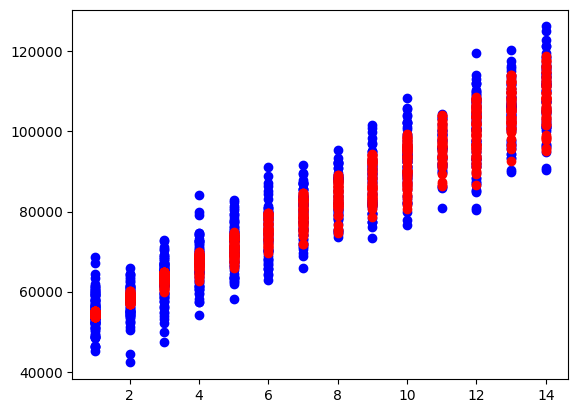

In [57]:
import matplotlib.pyplot as plt 

plt.scatter(df['Total Experience'], y , color="b")
plt.scatter(df['Total Experience'], y_pred, color='red')
